In [1]:
# Cell 1 — Imports + global setup
import itertools
import random
import time
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

GLOBAL_SEED = 42

# Experiment design
SEEDS = [0, 1, 2, 3, 4]          # show each seed
BUDGET = 60                      # model trainings per method per seed
GA_POP = 10
GA_GENS = 6                      
assert GA_POP * GA_GENS == BUDGET

# Training knobs 
MAX_ITERS = 80
EARLY_STOP = True

print("Seeds:", SEEDS)
print("Budget per method per seed:", BUDGET)
print("GA:", GA_POP, "pop x", GA_GENS, "gens")

Seeds: [0, 1, 2, 3, 4]
Budget per method per seed: 60
GA: 10 pop x 6 gens


In [2]:
# Cell 2 — Data + split
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=GLOBAL_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=GLOBAL_SEED, stratify=y_trainval
)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (1077, 64) (360, 64) (360, 64)


In [3]:
# Cell 3 — Search space + helpers

SEARCH_SPACE = {
    "lr": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "layers": [1, 2, 3],
    "width": [32, 64, 128, 256],
    "batch": [32, 64, 128],
    "activation": ["relu", "tanh"],
}

def make_hidden(layers: int, width: int) -> Tuple[int, ...]:
    return tuple([width] * layers)

def cfg_to_str(cfg: Dict) -> str:
    return f"lr={cfg['lr']}, layers={cfg['layers']}, width={cfg['width']}, batch={cfg['batch']}, act={cfg['activation']}"

def best_so_far_curve(scores: List[float]) -> List[float]:
    best = -1.0
    out = []
    for s in scores:
        best = max(best, s)
        out.append(best)
    return out

def sample_random_cfg(rng: random.Random) -> Dict:
    return {
        "lr": rng.choice(SEARCH_SPACE["lr"]),
        "layers": rng.choice(SEARCH_SPACE["layers"]),
        "width": rng.choice(SEARCH_SPACE["width"]),
        "batch": rng.choice(SEARCH_SPACE["batch"]),
        "activation": rng.choice(SEARCH_SPACE["activation"]),
    }

def build_pipeline(cfg: Dict, seed: int) -> Pipeline:
    hidden = make_hidden(cfg["layers"], cfg["width"])
    # # Initialize the fully connected neural network (FCNN) with the current hyperparameters.
    clf = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=cfg["activation"],
        solver="adam",
        learning_rate_init=cfg["lr"],
        batch_size=cfg["batch"],
        max_iter=MAX_ITERS,
        early_stopping=EARLY_STOP,
        n_iter_no_change=10,
        validation_fraction=0.1,
        random_state=seed,
        tol=1e-4,
        verbose=False,
    )
    return Pipeline([("scaler", StandardScaler()), ("mlp", clf)])

def train_eval_valacc(cfg: Dict, seed: int) -> float:
    pipe = build_pipeline(cfg, seed)
    pipe.fit(X_train, y_train)
    yhat = pipe.predict(X_val)
    return float(accuracy_score(y_val, yhat))

def train_eval_testacc(cfg: Dict, seed: int) -> float:
    # Train on train+val, evaluate on test (clean “final result”)
    pipe = build_pipeline(cfg, seed)
    pipe.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))
    yhat = pipe.predict(X_test)
    return float(accuracy_score(y_test, yhat))

# Precompute full grid, but we will only evaluate the first BUDGET points to keep equal budgets.
grid_all = list(itertools.product(
    SEARCH_SPACE["lr"], SEARCH_SPACE["layers"], SEARCH_SPACE["width"], SEARCH_SPACE["batch"], SEARCH_SPACE["activation"]
))
print("Total grid size:", len(grid_all))
print("Using first", BUDGET, "grid points per seed for fairness.")

Total grid size: 360
Using first 60 grid points per seed for fairness.


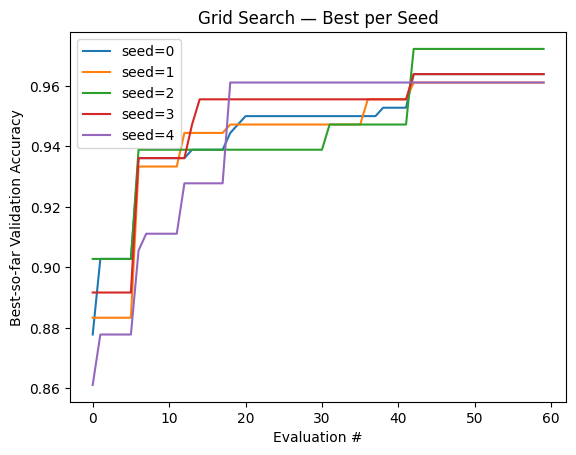

,seed,method,best_val_acc,best_test_acc,best_cfg,avg_val_acc,median_val_acc,avg_eval_time_s,total_time_s
0,2,Grid Search,0.972222,0.950000,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.887500,0.904167,0.593328,37.123548
1,0,Grid Search,0.963889,0.966667,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.888704,0.900000,0.611331,38.821156
2,3,Grid Search,0.963889,0.983333,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.887315,0.890278,0.652569,42.031101
3,1,Grid Search,0.961111,0.983333,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.887731,0.906944,0.594774,38.270205
4,4,Grid Search,0.961111,0.963889,"lr=0.0001, layers=1, width=256, batch=32, act=...",0.878194,0.906944,0.629373,38.913004


In [4]:
# Cell 4 — Baseline 1: Grid Search (all seeds) + per-seed visuals

grid_results = []     # row-wise results
grid_curves = {}      # seed -> best-so-far curve

for seed in SEEDS:
    scores = []
    cfgs = []
    eval_times = []

    start = time.time()
    for i, (lr, layers, width, batch, activation) in enumerate(grid_all[:BUDGET], start=1):
        cfg = {"lr": lr, "layers": layers, "width": width, "batch": batch, "activation": activation}

        t0 = time.time()
        acc = train_eval_valacc(cfg, seed=seed * 10_000 + i)   # deterministic per seed
        t1 = time.time()

        scores.append(acc)
        cfgs.append(cfg)
        eval_times.append(t1 - t0)

    best_idx = int(np.argmax(scores))
    best_cfg = cfgs[best_idx]
    best_val = scores[best_idx]
    best_test = train_eval_testacc(best_cfg, seed=seed * 10_000 + 99_999)

    grid_curves[seed] = best_so_far_curve(scores)

    grid_results.append({
        "seed": seed,
        "method": "Grid Search",
        "best_val_acc": best_val,
        "best_test_acc": best_test,
        "best_cfg": cfg_to_str(best_cfg),
        "avg_val_acc": float(np.mean(scores)),
        "median_val_acc": float(np.median(scores)),
        "avg_eval_time_s": float(np.mean(eval_times)),
        "total_time_s": float(time.time() - start),
    })

# Visual: show EACH seed curve for grid
plt.figure()
for seed in SEEDS:
    plt.plot(grid_curves[seed], label=f"seed={seed}")
plt.xlabel("Evaluation #")
plt.ylabel("Best-so-far Validation Accuracy")
plt.title("Grid Search — Best per Seed")
plt.legend()
plt.show()

pd.DataFrame(grid_results).sort_values(["best_val_acc"], ascending=False).reset_index(drop=True)